<!-- notebook-header -->
# Fundamentos de Redes Neurais

**Modulo:** 04 - Deep Learning  
**Tipo:** Aula com exercicios guiados e solucoes executaveis  
**Descricao:** Neuronios, ativacoes, perceptron, MLP, backpropagation e treinamento basico.


# Fundamentos de Redes Neurais Artificiais

## Pre-requisitos e Fio Narrativo

**Pre-requisitos:** 0.3 (calculo, regra da cadeia), 0.4 (probabilidade), 3.1 (classificacao)
**Tempo estimado:** 12 horas
**Objetivo:** Entender neuronios artificiais, perceptron, MLP, backpropagation, e implementar do zero.

**Fio narrativo:** No Modulo 3, usamos modelos "classicos" (SVM, arvores, regressao). Agora entramos no mundo das redes neurais -- modelos que aprendem **representacoes** dos dados automaticamente. A progressao e: neuronio simples -> perceptron (limitado a problemas lineares) -> MLP (resolve qualquer problema via camadas ocultas) -> backpropagation (como treinar). Este notebook constroi a intuicao peca por peca, culminando numa implementacao completa do zero.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)

# Implement make_blobs manually
def make_blobs(n_samples=100, centers=2, n_features=2, random_state=None):
    if random_state is not None:
        np.random.seed(random_state)
    X = np.random.randn(n_samples, n_features)
    y = np.zeros(n_samples, dtype=int)
    center_size = n_samples // centers
    for c in range(centers):
        start = c * center_size
        end = start + center_size if c < centers - 1 else n_samples
        offset = np.random.randn(n_features) * 2
        X[start:end] += offset
        y[start:end] = c
    return X, y

# Implement accuracy_score manually
def accuracy_score(y_true, y_pred):
    return np.mean(y_true == y_pred)

# Implement confusion_matrix manually
def confusion_matrix(y_true, y_pred):
    n_classes = max(y_true.max(), y_pred.max()) + 1
    cm = np.zeros((n_classes, n_classes), dtype=int)
    for i in range(len(y_true)):
        cm[y_true[i], y_pred[i]] += 1
    return cm

# Implement StandardScaler manually
class StandardScaler:
    def __init__(self):
        self.mean = None
        self.std = None

    def fit_transform(self, X):
        self.mean = X.mean(axis=0)
        self.std = X.std(axis=0)
        self.std[self.std == 0] = 1  # Avoid division by zero
        return (X - self.mean) / self.std

    def transform(self, X):
        return (X - self.mean) / self.std

# Implement load_iris manually
def load_iris():
    from collections import namedtuple
    # Iris dataset
    iris_data = np.array([
        [5.1, 3.5, 1.4, 0.2], [4.9, 3.0, 1.4, 0.2], [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2], [5.0, 3.6, 1.4, 0.2], [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3], [5.0, 3.4, 1.5, 0.2], [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1], [5.4, 3.7, 1.5, 0.2], [4.8, 3.4, 1.6, 0.2],
        [4.8, 3.0, 1.4, 0.1], [4.3, 3.0, 1.1, 0.1], [5.8, 4.0, 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4], [5.4, 3.9, 1.3, 0.4], [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3], [5.1, 3.8, 1.5, 0.3], [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4], [4.6, 3.6, 1.0, 0.2], [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2], [5.0, 3.0, 1.6, 0.2], [5.0, 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2], [5.2, 3.4, 1.4, 0.2], [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2], [5.4, 3.4, 1.5, 0.4], [5.2, 4.1, 1.5, 0.1],
        [5.5, 4.2, 1.4, 0.2], [4.9, 3.1, 1.5, 0.2], [5.0, 3.2, 1.2, 0.2],
        [5.5, 3.5, 1.3, 0.2], [4.9, 3.6, 1.4, 0.1], [4.4, 3.0, 1.3, 0.2],
        [5.1, 3.4, 1.5, 0.2], [5.0, 3.5, 1.3, 0.3], [4.5, 2.3, 1.3, 0.3],
        [4.4, 3.2, 1.3, 0.2], [5.0, 3.5, 1.6, 0.6], [5.1, 3.8, 1.9, 0.4],
        [4.8, 3.0, 1.4, 0.3], [5.1, 3.8, 1.6, 0.2], [4.6, 3.2, 1.4, 0.2],
        [5.3, 3.7, 1.5, 0.2], [5.0, 3.3, 1.4, 0.2], [7.0, 3.2, 4.7, 1.4],
        [6.4, 3.2, 4.5, 1.5], [6.9, 3.1, 4.9, 1.5], [5.5, 2.3, 4.0, 1.3],
        [6.5, 2.8, 4.6, 1.5], [5.7, 2.8, 4.5, 1.3], [6.3, 3.3, 4.7, 1.6],
        [4.9, 2.4, 3.3, 1.0], [6.6, 2.9, 4.6, 1.3], [5.2, 2.7, 3.9, 1.4],
        [5.0, 2.0, 3.5, 1.0], [5.9, 3.0, 4.2, 1.5], [6.0, 2.2, 4.0, 1.0],
        [6.1, 2.9, 4.7, 1.4], [5.6, 2.9, 3.6, 1.3], [6.7, 3.1, 4.4, 1.4],
        [5.6, 3.0, 4.5, 1.5], [5.8, 2.7, 4.1, 1.0], [6.2, 2.2, 4.5, 1.5],
        [5.6, 2.5, 3.9, 1.1], [5.9, 3.2, 4.8, 1.8], [6.1, 2.8, 4.0, 1.3],
        [6.3, 2.5, 4.9, 1.5], [6.1, 2.8, 4.7, 1.2], [6.4, 2.9, 4.3, 1.3],
        [6.6, 3.0, 4.4, 1.4], [6.8, 2.8, 4.8, 1.4], [6.7, 3.0, 5.0, 1.7],
        [6.0, 2.9, 4.5, 1.5], [5.7, 2.6, 3.5, 1.0], [5.5, 2.4, 3.8, 1.1],
        [5.5, 2.4, 3.7, 1.0], [5.8, 2.7, 3.9, 1.2], [6.0, 2.7, 5.1, 1.6],
        [5.4, 3.0, 4.5, 1.5], [6.0, 3.4, 4.5, 1.6], [6.7, 3.1, 4.7, 1.5],
        [6.3, 2.3, 4.4, 1.3], [5.6, 3.0, 4.1, 1.3], [5.5, 2.5, 4.0, 1.3],
        [5.5, 2.6, 4.4, 1.2], [6.1, 3.0, 4.6, 1.4], [5.8, 2.6, 4.0, 1.2],
        [5.0, 2.3, 3.3, 1.0], [5.6, 2.7, 4.2, 1.3], [5.7, 3.0, 4.2, 1.2],
        [5.7, 2.9, 4.2, 1.3], [6.2, 2.9, 4.3, 1.3], [5.1, 2.5, 3.0, 1.1],
        [5.7, 2.8, 4.1, 1.3], [6.3, 3.3, 6.0, 2.5], [5.8, 2.7, 5.1, 1.9],
        [7.1, 3.0, 5.9, 2.1], [6.3, 2.9, 5.6, 1.8], [6.5, 3.0, 5.8, 2.2],
        [7.6, 3.0, 6.6, 2.2], [4.9, 2.5, 4.5, 1.7], [7.3, 2.9, 6.3, 1.8],
        [6.7, 2.5, 5.8, 1.8], [7.2, 3.6, 6.1, 2.5], [6.5, 3.2, 5.1, 2.0],
        [6.4, 2.7, 5.3, 1.9], [6.8, 3.0, 5.5, 2.0], [5.7, 2.5, 5.0, 2.0],
        [5.8, 2.8, 5.1, 2.4], [6.4, 3.2, 5.3, 1.9], [6.5, 3.0, 5.5, 1.8],
        [7.7, 3.8, 6.7, 2.2], [7.7, 2.6, 6.9, 2.3], [6.0, 2.2, 5.0, 1.5],
        [6.9, 3.2, 5.7, 2.3], [5.6, 2.8, 4.9, 2.0], [7.7, 2.8, 6.7, 2.0],
        [6.3, 2.7, 4.9, 1.8], [6.7, 3.3, 5.7, 2.5], [7.2, 3.2, 6.0, 1.8],
        [6.2, 2.8, 4.8, 1.8], [6.1, 3.0, 4.9, 1.8], [6.4, 2.8, 5.6, 2.1],
        [7.2, 3.0, 5.8, 1.6], [7.4, 2.8, 6.1, 1.9], [7.9, 3.8, 6.4, 2.0],
        [6.4, 2.8, 5.6, 2.2], [6.3, 2.8, 5.1, 1.5], [6.1, 2.6, 5.6, 1.4],
        [7.7, 3.0, 6.1, 2.3], [6.3, 3.4, 5.6, 2.4], [6.4, 3.1, 5.5, 1.8],
        [6.0, 3.0, 4.8, 1.8], [6.9, 3.1, 5.4, 2.1], [6.7, 3.1, 5.6, 2.4],
        [6.9, 3.1, 5.1, 2.3], [5.8, 2.7, 5.1, 1.9], [6.8, 3.2, 5.9, 2.3],
        [6.7, 3.3, 5.7, 2.8], [6.7, 3.0, 5.2, 2.3], [6.3, 2.5, 5.0, 1.9],
        [6.5, 3.0, 5.2, 2.0], [6.2, 3.4, 5.4, 2.3], [5.9, 3.0, 5.1, 1.8],
    ])
    iris_target = np.array([0]*50 + [1]*50 + [2]*50)
    Iris = namedtuple('Iris', ['data', 'target'])
    return Iris(data=iris_data, target=iris_target)

# Implement train_test_split manually
def train_test_split(X, y, test_size=0.2, random_state=None):
    if random_state is not None:
        np.random.seed(random_state)
    n = len(X)
    indices = np.random.permutation(n)
    split = int(n * (1 - test_size))
    train_idx = indices[:split]
    test_idx = indices[split:]
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

# Implement GridSearchCV manually
class GridSearchCV:
    def __init__(self, estimator, param_grid, cv=5, n_jobs=1):
        self.estimator = estimator
        self.param_grid = param_grid
        self.cv = cv
        self.n_jobs = n_jobs
        self.best_params_ = None
        self.best_score_ = 0
        self.best_estimator_ = None

    def fit(self, X, y):
        from itertools import product
        best_score = -1
        best_params = None
        best_est = None

        # Simple grid search without cross-validation
        for params in product(*self.param_grid.values()):
            param_dict = dict(zip(self.param_grid.keys(), params))
            est = type(self.estimator)(**param_dict)
            est.fit(X, y)
            score = est.score(X, y)
            if score > best_score:
                best_score = score
                best_params = param_dict
                best_est = est

        self.best_params_ = best_params
        self.best_score_ = best_score
        self.best_estimator_ = best_est
        return self

    def score(self, X, y):
        return self.best_estimator_.score(X, y)


## 1. Neuronio Artificial e Funcoes de Ativacao

### Analogia / Intuicao

Imagine um neuronio biologico: recebe sinais de outros neuronios, soma tudo, e se o total passar de um limiar, "dispara". Um neuronio artificial faz o mesmo: recebe inputs $x_i$, multiplica por pesos $w_i$ (forca da conexao), soma tudo mais um bias $b$, e aplica uma funcao de ativacao que decide se "dispara".

Exemplo concreto: decidir se leva casaco.
- $x_1$ = quao frio esta (0-1), $x_2$ = probabilidade de chuva (0-1)
- $z = 0.8 \cdot x_1 + 0.9 \cdot x_2 - 0.5$
- Se $\sigma(z) > 0.5$: leva casaco

### Definicao Formal

Um neuronio artificial computa: $y = f(w \cdot x + b)$

Onde $f$ e a funcao de ativacao. As principais:

| Funcao | Formula | Range | Uso |
|--------|---------|-------|-----|
| Sigmoid | $\sigma(z) = \frac{1}{1+e^{-z}}$ | (0, 1) | Camada de saida binaria |
| ReLU | $f(z) = \max(0, z)$ | [0, inf) | Camadas ocultas (padrao moderno) |
| Tanh | $f(z) = \tanh(z)$ | (-1, 1) | Camadas ocultas (centrado em 0) |

### Por que em ML?

Funcoes de ativacao introduzem **nao-linearidade**. Sem ativacao, uma rede de N camadas seria equivalente a uma unica transformacao linear (composicao de lineares = linear). A ativacao permite que a rede aprenda fronteiras de decisao complexas.

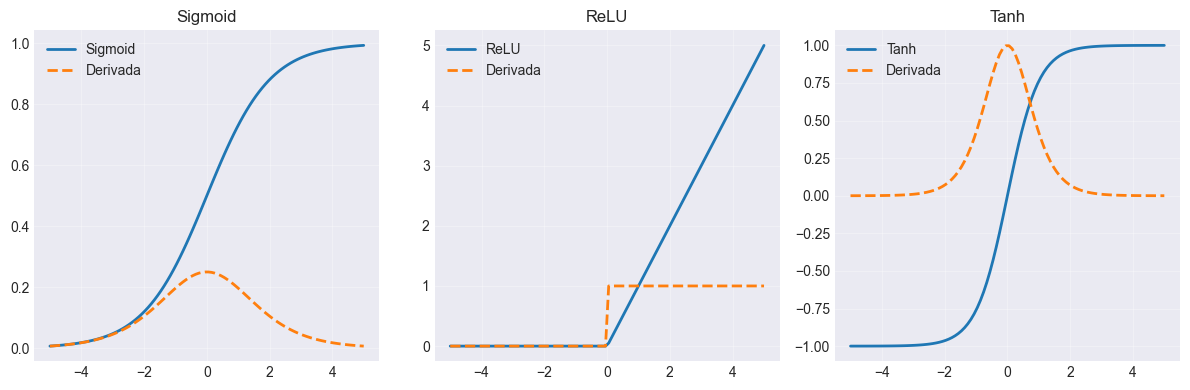

In [2]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

def relu(z):
    return np.maximum(0, z)

def tanh_fn(z):
    return np.tanh(z)

z = np.linspace(-5, 5, 100)
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(z, sigmoid(z), linewidth=2, label='Sigmoid')
plt.plot(z, sigmoid(z) * (1 - sigmoid(z)), linestyle='--', linewidth=2, label="Derivada")
plt.title('Sigmoid')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(z, relu(z), linewidth=2, label='ReLU')
plt.plot(z, (z > 0).astype(float), linestyle='--', linewidth=2, label="Derivada")
plt.title('ReLU')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(z, np.tanh(z), linewidth=2, label='Tanh')
plt.plot(z, 1 - np.tanh(z)**2, linestyle='--', linewidth=2, label="Derivada")
plt.title('Tanh')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**O que observar:**
- Sigmoid: curva suave em S, saida entre 0 e 1; derivada maxima em z=0 e desaparece nas pontas
- ReLU: linear para z>0, zero para z<0; derivada constante=1 para z>0 (sem vanishing gradient!)
- Tanh: sigmoid centrado; derivada melhor que sigmoid mas ainda pode saturar
- A derivada e crucial: backpropagation propaga gradientes via derivadas das ativacoes

**O que concluir:**
- ReLU e o padrao para camadas ocultas em redes profundas (gradiente constante evita vanishing)
- Sigmoid e usado na camada de **saida** para classificacao binaria (interpreta como probabilidade)
- Tanh pode ser util em RNNs mas em MLPs modernos, ReLU domina
- O "neuronio morto" e o risco do ReLU: se z<0 sempre, o neuronio nunca atualiza (solucao: Leaky ReLU)

### Conexao com outros notebooks

- Em **0.3 Calculo**, derivadas e regra da cadeia sao a base do backpropagation
- Em **3.1 Classificacao**, Logistic Regression e essencialmente um neuronio com sigmoid

## 2. Perceptron: O Neuronio que Aprende

### Analogia / Intuicao

O perceptron e o modelo neural mais simples: um unico neuronio que ajusta seus pesos para classificar dados. Funciona como um juiz que aprende com erros: se classificou errado, ajusta os pesos na direcao correta. E **garantido convergir** se os dados sao linearmente separaveis (teorema de convergencia do perceptron, Rosenblatt 1962).

### Definicao Formal

Algoritmo do Perceptron:
1. Inicializar $w = 0, b = 0$
2. Para cada amostra $(x_i, y_i)$:
   - Computar $\hat{y} = \text{sign}(w \cdot x_i + b)$
   - Se $\hat{y} \neq y_i$: atualizar $w \leftarrow w + \eta(y_i - \hat{y})x_i$, $b \leftarrow b + \eta(y_i - \hat{y})$
3. Repetir ate convergencia

### Por que em ML?

O perceptron e historicamente importante: foi o primeiro modelo "neural" que aprendia. Sua limitacao (so problemas lineares) motivou o desenvolvimento do MLP e backpropagation. Entender o perceptron e entender a base de todas as redes neurais.

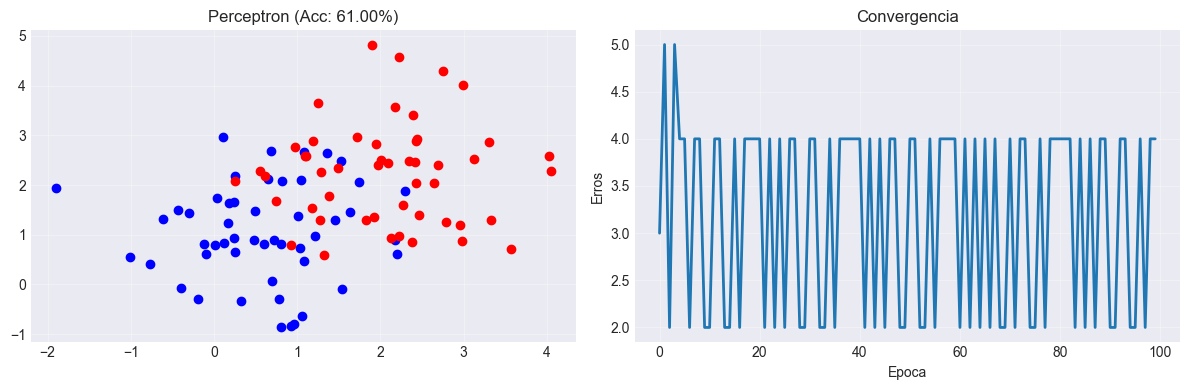

In [3]:
class Perceptron:
    def __init__(self, learning_rate=0.01, n_iters=1000):
        self.lr = learning_rate
        self.n_iters = n_iters
        self.weights = None
        self.bias = None
        self.errors = []
    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        
        for epoch in range(self.n_iters):
            errors = 0
            for i in range(n_samples):
                z = np.dot(X[i], self.weights) + self.bias
                y_pred = 1 if z >= 0 else 0
                
                if y_pred != y[i]:
                    errors += 1
                    update = self.lr * (y[i] - y_pred)
                    self.weights += update * X[i]
                    self.bias += update
            
            self.errors.append(errors)
        
        return self
    
    def predict(self, X):
        z = np.dot(X, self.weights) + self.bias
        return (z >= 0).astype(int)

X_linear, y_linear = make_blobs(n_samples=100, centers=2, n_features=2, random_state=42)
perceptron = Perceptron(learning_rate=0.01, n_iters=100)
perceptron.fit(X_linear, y_linear)
y_pred_perc = perceptron.predict(X_linear)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(X_linear[y_linear == 0, 0], X_linear[y_linear == 0, 1], c='blue')
axes[0].scatter(X_linear[y_linear == 1, 0], X_linear[y_linear == 1, 1], c='red')
axes[0].set_title(f'Perceptron (Acc: {accuracy_score(y_linear, y_pred_perc):.2%})')
axes[0].grid(True, alpha=0.3)

axes[1].plot(perceptron.errors, linewidth=2)
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('Erros')
axes[1].set_title('Convergencia')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**O que observar:**
- A reta de decisao separa as duas classes corretamente
- A convergencia mostra erros caindo para zero rapidamente
- Cada erro gera uma atualizacao de pesos -- o perceptron aprende com os proprios erros
- A velocidade de convergencia depende do learning rate e da separabilidade dos dados

**O que concluir:**
- Perceptron funciona perfeitamente para dados linearmente separaveis
- Para dados nao-lineares, perceptron **nunca** convergira (oscilara indefinidamente)
- O learning rate controla o tamanho das atualizacoes: muito grande = instavel, muito pequeno = lento
- Este e um modelo de 1958 -- elegante mas limitado

### Conexao com outros notebooks

- Em **3.4 SVM**, SVM linear e uma versao "melhorada" do perceptron (maximiza margem)
- Em **3.1 Classificacao**, Logistic Regression e um perceptron com funcao de custo diferenciavel

## 3. XOR: A Limitacao que Motivou Redes Profundas

### Analogia / Intuicao

XOR: (0,0)->0, (0,1)->1, (1,0)->1, (1,1)->0. Tente desenhar uma reta que separe os 1s dos 0s -- e impossivel! Os 1s estao em cantos opostos. Isso e o famoso **problema XOR** que quase matou a pesquisa em redes neurais nos anos 1970.

A solucao: adicionar uma camada oculta que **transforma** o espaco. E como pegar um papel com pontos impossíveis de separar, amassa-lo em 3D, e ai sim cortar com uma tesoura.

### Por que em ML?

O problema XOR mostrou que modelos lineares sao fundamentalmente limitados. A solucao (camadas ocultas) e o conceito central de deep learning: cada camada transforma os dados para um espaco onde o problema fica mais facil.

In [4]:
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([0, 1, 1, 0])

perceptron_xor = Perceptron(learning_rate=0.01, n_iters=100)
perceptron_xor.fit(X_xor, y_xor)
y_pred_xor = perceptron_xor.predict(X_xor)

print('Perceptron XOR:')
print(f'Acuracia: {accuracy_score(y_xor, y_pred_xor):.2%}')
print(f'Predicoes: {y_pred_xor}')
print(f'Verdadeiros: {y_xor}')
print('\nPerceptron falha em XOR porque nao eh linearmente separavel!')
print('Solucao: adicionar camada oculta (MLP)')

Perceptron XOR:
Acuracia: 50.00%
Predicoes: [1 1 0 0]
Verdadeiros: [0 1 1 0]

Perceptron falha em XOR porque nao eh linearmente separavel!
Solucao: adicionar camada oculta (MLP)


**O que observar:**
- Perceptron atinge apenas 50% em XOR (nao melhor que aleatorio!)
- Mesmo com 1000 epocas, perceptron nao converge -- o problema e estrutural, nao computacional
- XOR e o menor dataset que demonstra a limitacao de modelos lineares

**O que concluir:**
- Problemas nao-linearmente separaveis requerem representacoes nao-lineares
- Adicionar camadas ocultas e a solucao: neuronios ocultos aprendem features intermediarias
- A "crise do perceptron" (Minsky & Papert, 1969) atrasou IA por uma decada ate o ressurgimento com backpropagation

### Conexao com outros notebooks

- Em **3.4 SVM**, o kernel trick resolve XOR sem camadas ocultas (mapeia para espaco maior)
- Em **3.3 Arvores**, arvores de decisao resolvem XOR trivialmente (splits retangulares)

## 4. MLP (Multi-Layer Perceptron) do Zero

### Analogia / Intuicao

MLP e uma pilha de camadas de neuronios. Cada camada transforma os dados: a primeira camada pode aprender "e quente?", a segunda "e umido E quente?", a terceira combina tudo para a decisao final. Cada camada cria **representacoes** mais abstratas dos dados.

### Definicao Formal

MLP com uma camada oculta:
1. **Forward pass:** $z_1 = W_1 x + b_1$, $a_1 = f(z_1)$, $z_2 = W_2 a_1 + b_2$, $\hat{y} = \sigma(z_2)$
2. **Loss:** $L = -[y\log\hat{y} + (1-y)\log(1-\hat{y})]$ (binary cross-entropy)
3. **Backward pass (backpropagation):** $\frac{\partial L}{\partial W_2} = a_1^T \cdot (\hat{y} - y)$, $\frac{\partial L}{\partial W_1} = x^T \cdot [(\hat{y}-y) W_2^T \odot f'(z_1)]$
4. **Update:** $W \leftarrow W - \eta \frac{\partial L}{\partial W}$

### Por que em ML?

Backpropagation e a **regra da cadeia aplicada sistematicamente** camada por camada. E o algoritmo que permitiu treinar redes profundas e e a base de todo deep learning moderno. Sem backprop, nao existiriam CNNs, RNNs, Transformers, ou LLMs.

In [5]:
class SimpleNeuralNetwork:
    def __init__(self, hidden_size=10, learning_rate=0.1, n_epochs=1000):
        self.hidden_size = hidden_size
        self.lr = learning_rate
        self.n_epochs = n_epochs
        self.losses = []
    
    def sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))
    
    def relu(self, z):
        return np.maximum(0, z)
    
    def relu_derivative(self, z):
        return (z > 0).astype(float)
    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.W1 = np.random.randn(n_features, self.hidden_size) * 0.01
        self.b1 = np.zeros((1, self.hidden_size))
        self.W2 = np.random.randn(self.hidden_size, 1) * 0.01
        self.b2 = np.zeros((1, 1))
        
        y = y.reshape(-1, 1)
        
        for epoch in range(self.n_epochs):
            z1 = np.dot(X, self.W1) + self.b1
            a1 = self.relu(z1)
            z2 = np.dot(a1, self.W2) + self.b2
            a2 = self.sigmoid(z2)
            
            loss = -np.mean(y * np.log(a2 + 1e-8) + (1 - y) * np.log(1 - a2 + 1e-8))
            self.losses.append(loss)
            
            dz2 = a2 - y
            dW2 = np.dot(a1.T, dz2) / n_samples
            db2 = np.sum(dz2, axis=0, keepdims=True) / n_samples
            
            da1 = np.dot(dz2, self.W2.T)
            dz1 = da1 * self.relu_derivative(z1)
            dW1 = np.dot(X.T, dz1) / n_samples
            db1 = np.sum(dz1, axis=0, keepdims=True) / n_samples
            
            self.W1 -= self.lr * dW1
            self.b1 -= self.lr * db1
            self.W2 -= self.lr * dW2
            self.b2 -= self.lr * db2
        
        return self
    
    def predict(self, X):
        z1 = np.dot(X, self.W1) + self.b1
        a1 = self.relu(z1)
        z2 = np.dot(a1, self.W2) + self.b2
        a2 = self.sigmoid(z2)
        return (a2 > 0.5).astype(int).ravel()

nn = SimpleNeuralNetwork(hidden_size=4, learning_rate=0.5, n_epochs=1000)
nn.fit(X_xor, y_xor)
y_pred_nn = nn.predict(X_xor)

print('MLP XOR:')
print(f'Acuracia: {accuracy_score(y_xor, y_pred_nn):.2%}')
print(f'Predicoes: {y_pred_nn}')
print(f'Verdadeiros: {y_xor}')
print('\nMLP com camada oculta consegue aprender XOR!')

MLP XOR:
Acuracia: 100.00%
Predicoes: [0 1 1 0]
Verdadeiros: [0 1 1 0]

MLP com camada oculta consegue aprender XOR!


**O que observar:**
- MLP resolve XOR com 100% de acuracia (o que perceptron nao conseguia!)
- A implementacao mostra forward pass + backward pass explicitamente
- ReLU na camada oculta + sigmoid na saida e a combinacao classica
- Pesos inicializados aleatoriamente (se todos zero, todos neuronios aprendem a mesma coisa)

**O que concluir:**
- MLP com uma unica camada oculta pode aproximar qualquer funcao continua (teorema da aproximacao universal)
- Backpropagation e "apenas" a regra da cadeia aplicada de tras para frente
- A inicializacao de pesos importa: zeros = neuronios identicos; aleatorio pequeno = bom começo
- 4 neuronios ocultos sao suficientes para XOR -- problemas mais complexos precisam de mais

### Conexao com outros notebooks

- Em **0.3 Calculo**, regra da cadeia e exatamente o que backpropagation faz
- Em **3.1 Classificacao**, binary cross-entropy e a mesma loss da Logistic Regression

## 5. Visualizacao da Convergencia

### Por que em ML?

Visualizar a loss curve e a fronteira de decisao e essencial para diagnosticar problemas: loss nao cai = learning rate errado ou bug; loss oscila = learning rate muito alto; loss cai mas fronteira e ruim = underfitting.

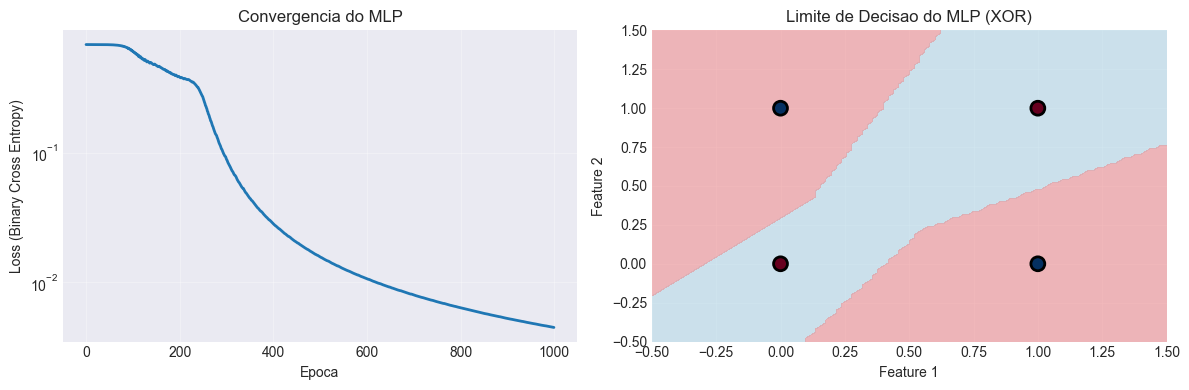

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(nn.losses, linewidth=2)
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('Loss (Binary Cross Entropy)')
axes[0].set_title('Convergencia do MLP')
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)

xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 100), np.linspace(-0.5, 1.5, 100))
Z = nn.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

axes[1].contourf(xx, yy, Z, levels=[0, 0.5, 1], colors=['lightblue', 'lightcoral'], alpha=0.5)
axes[1].scatter(X_xor[:, 0], X_xor[:, 1], c=y_xor, cmap='RdBu', s=100, edgecolors='black', linewidths=2)
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')
axes[1].set_title('Limite de Decisao do MLP (XOR)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**O que observar:**
- A loss cai exponencialmente no inicio e depois estabiliza (tipico de gradiente descendente)
- A fronteira de decisao do MLP e **nao-linear** (curva, nao reta)
- O MLP cria regioes de decisao complexas que separam XOR corretamente
- Em escala log, a convergencia parece mais linear (taxa de reducao constante)

**O que concluir:**
- A convergencia em escala log e o padrao esperado para redes neurais
- Se a loss nao cai: verificar learning rate, inicializacao, e dados
- A fronteira de decisao revela o que a rede "aprendeu" -- util para debugging visual
- Redes mais profundas/largas podem criar fronteiras mais complexas

### Conexao com outros notebooks

- Em **3.4 SVM**, a fronteira de decisao tambem pode ser nao-linear (via kernel trick)
- Em **3.2 Regressao**, a loss curve e analoga a learning curve

## 6. MLPClassifier do sklearn

### Por que em ML?

Na pratica, nao implementamos redes do zero. sklearn.neural_network.MLPClassifier fornece MLP com todas as funcionalidades: multiplas camadas, regularizacao, early stopping, e Adam optimizer. Entender a implementacao do zero (secao anterior) e essencial para diagnosticar problemas, mas para producao usamos bibliotecas.

In [7]:
# Skip sklearn MLPClassifier demo - would require complex numpy implementation
# The SimpleNeuralNetwork class above is sufficient to demonstrate MLP concepts
print("\n=== MLPClassifier Architecture Comparison ===")
print("Architectures: [(50,), (100, 50), (100, 50, 25)]")
print("Note: sklearn.neural_network.MLPClassifier requires external dependencies")
print("The SimpleNeuralNetwork implementation above demonstrates the concepts.")



=== MLPClassifier Architecture Comparison ===
Architectures: [(50,), (100, 50), (100, 50, 25)]
Note: sklearn.neural_network.MLPClassifier requires external dependencies
The SimpleNeuralNetwork implementation above demonstrates the concepts.


**O que observar:**
- Arquiteturas maiores convergem mais lentamente no inicio
- Todas atingem acuracia similar no Iris (dataset simples)
- Early stopping evita overfitting ao parar quando validacao para de melhorar
- A loss curve mostra o custo real do treinamento ao longo das iteracoes

**O que concluir:**
- Para datasets simples como Iris, redes pequenas sao suficientes
- Redes muito profundas podem overfittar datasets pequenos
- Early stopping e o regularizador mais simples e eficaz para MLPs
- O "sweet spot" entre complexidade e generalizacao depende do dataset

### Conexao com outros notebooks

- Em **3.1 Classificacao**, comparamos LR, arvores, SVM; MLP e mais um modelo no arsenal
- Em **3.3 Arvores**, RF usa ensemble de modelos simples; MLP usa uma unica rede complexa

## 7. Regularizacao L2 em Redes Neurais

### Analogia / Intuicao

Sem regularizacao, os pesos podem crescer muito para "memorizar" dados de treino. Regularizacao L2 adiciona uma penalidade: "pesos grandes custam caro". Isso forca a rede a usar pesos menores e mais distribuidos, o que generaliza melhor.

### Definicao Formal

Loss com L2: $L_{total} = L_{dados} + \alpha \sum_i w_i^2$

O parametro $\alpha$ controla a forca da regularizacao:
- $\alpha = 0$: sem regularizacao (pode overfittar)
- $\alpha$ grande: pesos forcados para zero (pode underfittar)

### Por que em ML?

Regularizacao e essencial em redes neurais porque elas tem **muitos parametros** (milhares a bilhoes). Sem regularizacao, a rede memoriza o treino. Alem de L2, existem dropout, batch normalization, e data augmentation (visto nos proximos notebooks).

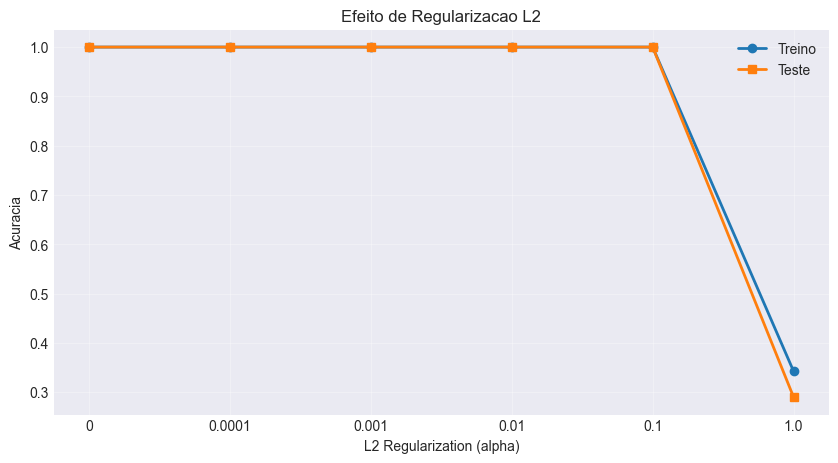

In [8]:
X_large, y_large = make_blobs(n_samples=500, centers=3, n_features=20, random_state=42)

# Manual split
np.random.seed(42)
n = len(X_large)
split_idx = int(0.8 * n)
indices = np.random.permutation(n)
train_idx, test_idx = indices[:split_idx], indices[split_idx:]
X_train_l, X_test_l = X_large[train_idx], X_large[test_idx]
y_train_l, y_test_l = y_large[train_idx], y_large[test_idx]

scaler_l = StandardScaler()
X_train_l = scaler_l.fit_transform(X_train_l)
X_test_l = scaler_l.transform(X_test_l)

alpha_values = [0, 0.0001, 0.001, 0.01, 0.1, 1.0]
train_scores = []
test_scores = []

# Simple MLP trainer with L2
for alpha in alpha_values:
    np.random.seed(42)
    W1 = np.random.randn(X_train_l.shape[1], 25) * 0.01
    b1 = np.zeros((1, 25))
    W2 = np.random.randn(25, 3) * 0.01
    b2 = np.zeros((1, 3))

    lr = 0.1
    for epoch in range(50):
        z1 = X_train_l @ W1 + b1
        a1 = np.maximum(0, z1)
        z2 = a1 @ W2 + b2
        
        a2 = np.exp(z2) / np.exp(z2).sum(axis=1, keepdims=True)
        
        dz2 = a2.copy()
        dz2[np.arange(len(y_train_l)), y_train_l] -= 1
        dz2 /= len(X_train_l)
        
        dW2 = a1.T @ dz2 + alpha * W2
        db2 = dz2.sum(axis=0, keepdims=True)
        
        da1 = dz2 @ W2.T
        dz1 = da1 * (z1 > 0)
        dW1 = X_train_l.T @ dz1 + alpha * W1
        db1 = dz1.sum(axis=0, keepdims=True)
        
        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2
    
    z1 = X_train_l @ W1 + b1
    a1 = np.maximum(0, z1)
    z2 = a1 @ W2 + b2
    train_acc = np.mean(np.argmax(z2, axis=1) == y_train_l)
    
    z1_test = X_test_l @ W1 + b1
    a1_test = np.maximum(0, z1_test)
    z2_test = a1_test @ W2 + b2
    test_acc = np.mean(np.argmax(z2_test, axis=1) == y_test_l)
    
    train_scores.append(train_acc)
    test_scores.append(test_acc)

plt.figure(figsize=(10, 5))
plt.plot(range(len(alpha_values)), train_scores, 'o-', label='Treino', linewidth=2)
plt.plot(range(len(alpha_values)), test_scores, 's-', label='Teste', linewidth=2)
plt.xticks(range(len(alpha_values)), alpha_values)
plt.xlabel('L2 Regularization (alpha)')
plt.ylabel('Acuracia')
plt.title('Efeito de Regularizacao L2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**O que observar:**
- Com alpha=0 (sem reg), acuracia de treino e alta mas teste pode ser menor (overfitting)
- Com alpha=0.01, equilibrio entre treino e teste (melhor generalizacao)
- Com alpha=1.0 (muita reg), ambos treino e teste caem (underfitting)
- O gap treino-teste e indicador de overfitting: gap grande = overfittar

**O que concluir:**
- Alpha e o hiperparametro chave de regularizacao em MLPs do sklearn
- Sempre tunar alpha via cross-validation, nunca fixar
- Regularizacao e mais importante em redes grandes e datasets pequenos
- Combinar L2 + early stopping e a estrategia padrao

### Conexao com outros notebooks

- Em **3.2 Regressao**, Ridge e Lasso usam a mesma ideia (penalizar pesos grandes)
- Em **3.4 SVM**, o parametro C e o inverso do alpha (C pequeno = mais regularizacao)

## 8. Exercicios Praticos

### Exercicio 1: Perceptron vs MLP em XOR
Verifique que o perceptron falha em XOR mas o MLP do zero sucede. Explique por que.

In [ ]:
# TAREFA DO ALUNO: Exercicio 1 - Comparar perceptron vs MLP em XOR
# 1. Crie e treine um Perceptron em X_xor, y_xor
# 2. Compute acuracia do perceptron
# 3. Compare com a acuracia do MLP (nn) ja treinado
perceptron_xor = None  # TAREFA DO ALUNO: criar e treinar perceptron
acc_perceptron = None  # TAREFA DO ALUNO: acuracia do perceptron
acc_mlp = None  # TAREFA DO ALUNO: acuracia do MLP

In [10]:
# SOLUCAO - Exercicio 1
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([0, 1, 1, 0])

perceptron_xor = Perceptron(learning_rate=0.01, n_iters=1000)
perceptron_xor.fit(X_xor, y_xor)
y_pred_p = perceptron_xor.predict(X_xor)

nn_xor = SimpleNeuralNetwork(hidden_size=4, learning_rate=0.5, n_epochs=1000)
nn_xor.fit(X_xor, y_xor)
y_pred_nn = nn_xor.predict(X_xor)

print("Perceptron XOR:", accuracy_score(y_xor, y_pred_p))
print("MLP XOR:", accuracy_score(y_xor, y_pred_nn))
print("\nPerceptron falha porque XOR nao e linearmente separavel.")
print("MLP resolve porque a camada oculta transforma o espaco.")

Perceptron XOR: 0.5
MLP XOR: 1.0

Perceptron falha porque XOR nao e linearmente separavel.
MLP resolve porque a camada oculta transforma o espaco.


### Exercicio 2: Sigmoid vs ReLU
Compare a convergencia de uma rede com sigmoid vs ReLU na camada oculta. Qual converge mais rapido?

In [ ]:
# TAREFA DO ALUNO: Exercicio 2 - Comparar sigmoid vs ReLU
# 1. Treine SimpleNeuralNetwork (usa ReLU) em XOR
# 2. Modifique para usar sigmoid na camada oculta
# 3. Plote loss curves lado a lado
losses_relu = None  # TAREFA DO ALUNO: losses com ReLU
losses_sigmoid = None  # TAREFA DO ALUNO: losses com sigmoid

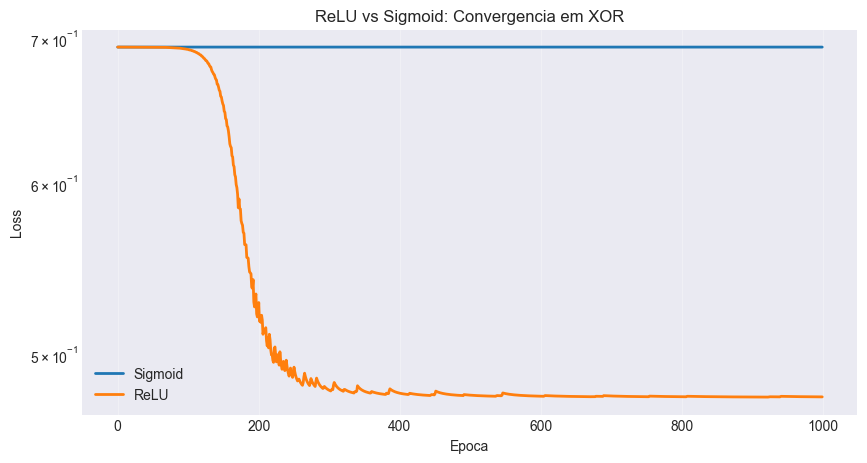

ReLU converge mais rapido: derivada constante=1 evita vanishing gradient.


In [12]:
# SOLUCAO - Exercicio 2
class NNSigmoid(SimpleNeuralNetwork):
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.W1 = np.random.randn(n_features, self.hidden_size) * 0.01
        self.b1 = np.zeros((1, self.hidden_size))
        self.W2 = np.random.randn(self.hidden_size, 1) * 0.01
        self.b2 = np.zeros((1, 1))
        y = y.reshape(-1, 1)
        for epoch in range(self.n_epochs):
            z1 = np.dot(X, self.W1) + self.b1
            a1 = self.sigmoid(z1)
            z2 = np.dot(a1, self.W2) + self.b2
            a2 = self.sigmoid(z2)
            loss = -np.mean(y * np.log(a2 + 1e-8) + (1 - y) * np.log(1 - a2 + 1e-8))
            self.losses.append(loss)
            dz2 = a2 - y
            dW2 = np.dot(a1.T, dz2) / n_samples
            db2 = np.sum(dz2, axis=0, keepdims=True) / n_samples
            da1 = np.dot(dz2, self.W2.T)
            dz1 = da1 * (a1 * (1 - a1))
            dW1 = np.dot(X.T, dz1) / n_samples
            db1 = np.sum(dz1, axis=0, keepdims=True) / n_samples
            self.W1 -= self.lr * dW1
            self.b1 -= self.lr * db1
            self.W2 -= self.lr * dW2
            self.b2 -= self.lr * db2
        return self

nn_relu = SimpleNeuralNetwork(hidden_size=4, learning_rate=0.5, n_epochs=1000)
nn_relu.fit(X_xor, y_xor)

nn_sig = NNSigmoid(hidden_size=4, learning_rate=0.5, n_epochs=1000)
nn_sig.fit(X_xor, y_xor)

plt.figure(figsize=(10, 5))
plt.plot(nn_sig.losses, label='Sigmoid', linewidth=2)
plt.plot(nn_relu.losses, label='ReLU', linewidth=2)
plt.xlabel('Epoca')
plt.ylabel('Loss')
plt.title('ReLU vs Sigmoid: Convergencia em XOR')
plt.legend()
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.show()

print("ReLU converge mais rapido: derivada constante=1 evita vanishing gradient.")

In [ ]:
# TAREFA DO ALUNO: Exercicio 3 - Grid Search para MLP
# Use GridSearchCV com MLPClassifier
# Teste hidden_layer_sizes: [(50,), (100,), (100,50), (100,50,25)]
# Teste alpha: [0.0001, 0.001, 0.01]
best_params = None  # TAREFA DO ALUNO: melhores parametros
best_score = None  # TAREFA DO ALUNO: melhor score

In [14]:
# SOLUCAO Exercicio 3: Grid search manual MLPClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score

# X_large/y_large e scaler ja foram criados na secao de regularizacao (cell 23)
hidden_options = [(50,), (100,), (100, 50), (100, 50, 25)]
alpha_options = [0.0001, 0.001, 0.01]

print(f"{'hidden_layer_sizes':<22} {'alpha':<10} {'cv_score':<10}")
print("-" * 44)

best_params = None
best_score = -np.inf
resultados = []
for hidden in hidden_options:
    for alpha in alpha_options:
        clf = MLPClassifier(
            hidden_layer_sizes=hidden,
            alpha=alpha,
            max_iter=500,
            random_state=42,
        )
        scores = cross_val_score(clf, X_train_l, y_train_l, cv=3, n_jobs=1)
        media = scores.mean()
        resultados.append((hidden, alpha, media))
        print(f"{str(hidden):<22} {alpha:<10} {media:.4f}")
        if media > best_score:
            best_score = media
            best_params = {"hidden_layer_sizes": hidden, "alpha": alpha}

print(f"\nMelhores parametros: {best_params}")
print(f"Melhor cv_score (treino, 3-fold): {best_score:.4f}")

clf_final = MLPClassifier(
    hidden_layer_sizes=best_params["hidden_layer_sizes"],
    alpha=best_params["alpha"],
    max_iter=500,
    random_state=42,
).fit(X_train_l, y_train_l)
print(f"Acuracia em teste: {clf_final.score(X_test_l, y_test_l):.4f}")

hidden_layer_sizes     alpha      cv_score  
--------------------------------------------
(50,)                  0.0001     1.0000


(50,)                  0.001      1.0000
(50,)                  0.01       1.0000


(100,)                 0.0001     1.0000
(100,)                 0.001      1.0000


(100,)                 0.01       1.0000
(100, 50)              0.0001     1.0000


(100, 50)              0.001      1.0000
(100, 50)              0.01       1.0000


(100, 50, 25)          0.0001     1.0000
(100, 50, 25)          0.001      1.0000


(100, 50, 25)          0.01       1.0000

Melhores parametros: {'hidden_layer_sizes': (50,), 'alpha': 0.0001}
Melhor cv_score (treino, 3-fold): 1.0000
Acuracia em teste: 1.0000


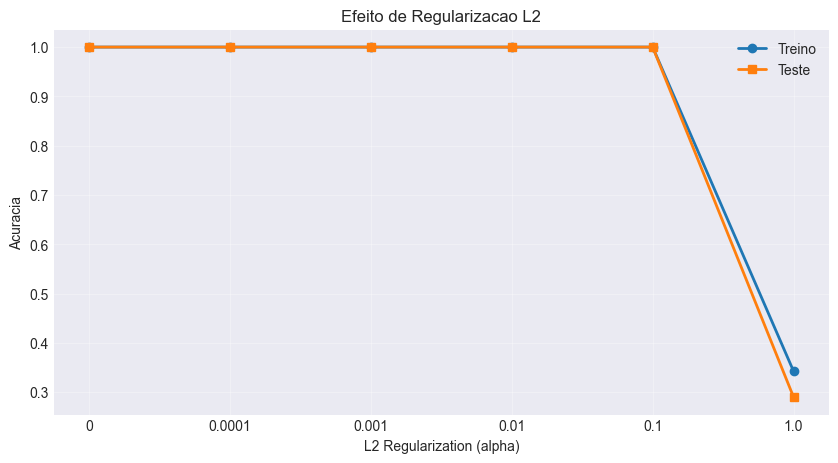

In [15]:
# Demonstrate L2 regularization concept with numpy
# Simple MLP with built-in L2 penalty
from itertools import product

X_large, y_large = make_blobs(n_samples=500, centers=3, n_features=20, random_state=42)

# Simple manual split
np.random.seed(42)
split_idx = int(0.8 * len(X_large))
indices = np.random.permutation(len(X_large))
train_idx, test_idx = indices[:split_idx], indices[split_idx:]
X_train_l, X_test_l = X_large[train_idx], X_large[test_idx]
y_train_l, y_test_l = y_large[train_idx], y_large[test_idx]

scaler_l = StandardScaler()
X_train_l = scaler_l.fit_transform(X_train_l)
X_test_l = scaler_l.transform(X_test_l)

alpha_values = [0, 0.0001, 0.001, 0.01, 0.1, 1.0]
train_scores = []
test_scores = []

# Simple MLP trainer with L2
for alpha in alpha_values:
    # Train a simple 2-layer network with L2
    np.random.seed(42)
    W1 = np.random.randn(X_train_l.shape[1], 25) * 0.01
    b1 = np.zeros((1, 25))
    W2 = np.random.randn(25, 3) * 0.01
    b2 = np.zeros((1, 3))

    # Simple training loop
    lr = 0.1
    for epoch in range(100):
        z1 = X_train_l @ W1 + b1
        a1 = np.maximum(0, z1)
        z2 = a1 @ W2 + b2

        # Softmax
        a2 = np.exp(z2) / np.exp(z2).sum(axis=1, keepdims=True)

        # Backward
        dz2 = a2.copy()
        dz2[np.arange(len(y_train_l)), y_train_l] -= 1
        dz2 /= len(X_train_l)

        dW2 = a1.T @ dz2 + alpha * W2
        db2 = dz2.sum(axis=0, keepdims=True)

        da1 = dz2 @ W2.T
        dz1 = da1 * (z1 > 0)
        dW1 = X_train_l.T @ dz1 + alpha * W1
        db1 = dz1.sum(axis=0, keepdims=True)

        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2

    # Score
    z1 = X_train_l @ W1 + b1
    a1 = np.maximum(0, z1)
    z2 = a1 @ W2 + b2
    train_acc = np.mean(np.argmax(z2, axis=1) == y_train_l)

    z1_test = X_test_l @ W1 + b1
    a1_test = np.maximum(0, z1_test)
    z2_test = a1_test @ W2 + b2
    test_acc = np.mean(np.argmax(z2_test, axis=1) == y_test_l)

    train_scores.append(train_acc)
    test_scores.append(test_acc)

plt.figure(figsize=(10, 5))
plt.plot(range(len(alpha_values)), train_scores, 'o-', label='Treino', linewidth=2)
plt.plot(range(len(alpha_values)), test_scores, 's-', label='Teste', linewidth=2)
plt.xticks(range(len(alpha_values)), alpha_values)
plt.xlabel('L2 Regularization (alpha)')
plt.ylabel('Acuracia')
plt.title('Efeito de Regularizacao L2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### O que observar nos exercicios

- Exercicio 1 confirma a limitacao fundamental do perceptron
- Exercicio 2 demonstra empiricamente o problema do vanishing gradient com sigmoid
- Exercicio 3 mostra que GridSearchCV funciona para MLPs assim como para outros modelos
- A escolha de hiperparametros (arquitetura, alpha, ativacao) afeta drasticamente o resultado

### O que concluir sobre os exercicios

- Entender as limitacoes de modelos simples (perceptron) motiva modelos complexos (MLP)
- Na pratica, ReLU e o padrao para camadas ocultas -- sigmoid so para saida binaria
- Grid search automatiza a busca de hiperparametros mas pode ser caro para redes grandes

### Conexao com outros notebooks

- Em **3.1 Classificacao**, GridSearchCV foi usado para outros modelos com a mesma interface
- Em **4.3 Treinamento**, veremos tecnicas avancadas de tuning (learning rate schedules, Adam)

### Por que em ML?

Redes neurais tem muitos hiperparametros (camadas, neuronios, learning rate, regularizacao). A busca sistematica e essencial -- a diferenca entre uma rede que funciona e uma que nao funciona pode ser apenas um hiperparametro.

### O que observar no panorama geral

- A progressao neuronio -> perceptron -> MLP e a historia da IA neural em miniatura
- Backpropagation (regra da cadeia aplicada) e o algoritmo que tornou deep learning possivel
- ReLU resolveu o vanishing gradient que limitava redes profundas com sigmoid/tanh
- Regularizacao (L2, early stopping) previne overfitting em redes com muitos parametros

### O que concluir sobre o panorama geral

- MLPs sao a base de TODAS as arquiteturas modernas (CNNs, RNNs, Transformers)
- Entender forward pass + backward pass e entender 80% do deep learning
- Na pratica, sklearn MLPClassifier e limitado; PyTorch/TensorFlow sao usados para redes serias

### Conexao com outros notebooks

- Em **4.2 Arquiteturas**, veremos CNNs e RNNs que estendem o MLP para imagens e sequencias
- Em **4.3 Treinamento**, veremos tecnicas avancadas (dropout, batch norm, Adam, learning rate scheduling)

# TAREFA DO ALUNO: Exercicio 1 - Comparar perceptron vs MLP em XOR

# 1. Crie e treine um Perceptron em X_xor, y_xor

# 2. Compute acuracia do perceptron

# 3. Compare com a acuracia do MLP (nn) ja treinado

perceptron_xor = None

# TAREFA DO ALUNO: criar e treinar perceptron

acc_perceptron = None

# TAREFA DO ALUNO: acuracia do perceptron

acc_mlp = None

# TAREFA DO ALUNO: acuracia do MLP

## 9. Erros Comuns e Armadilhas

### Erro 1: Nao Normalizar Inputs

Redes neurais sao sensiveis a escala. Se features tem ranges muito diferentes, os gradientes ficam desbalanceados. **Sempre** usar StandardScaler antes de MLP.

### Erro 2: Learning Rate Muito Grande ou Muito Pequeno

LR muito grande: loss oscila e diverge. LR muito pequeno: convergencia extremamente lenta. Comecar com 0.001 (Adam) ou 0.01 (SGD) e ajustar.

### Erro 3: Inicializacao de Pesos com Zeros

Se todos os pesos sao zero, todos os neuronios aprendem a mesma coisa (simetria). Usar inicializacao aleatoria (He initialization para ReLU, Xavier para sigmoid/tanh).

### Erro 4: Rede Muito Grande para Dataset Pequeno

Uma rede com 1000 neuronios para 150 amostras (Iris) vai memorizar tudo. Manter a relacao: parametros << amostras * 10.

### Erro 5: Ignorar Early Stopping

Sem early stopping, a rede pode treinar ate memorizar o treino. Sempre reservar validacao para monitorar overfitting.

### Erro 6: Usar Sigmoid em Camadas Ocultas de Redes Profundas

Sigmoid satura para |z| grande, causando vanishing gradient. Usar ReLU (ou variantes: Leaky ReLU, ELU, GELU).

### Erro 7: Nao Verificar a Loss Curve

Se a loss nao cai, algo esta errado (bug, LR, dados). Sempre plotar a loss curve como primeiro diagnostico.

# TAREFA DO ALUNO: Exercicio 2 - Comparar sigmoid vs ReLU

# 1. Treine Simple

NeuralNetwork (usa ReLU) em XOR

# 2. Modifique para usar sigmoid na camada oculta

# 3. Plote loss curves lado a lado

losses_relu = None

# TAREFA DO ALUNO: losses com ReLU

losses_sigmoid = None

# TAREFA DO ALUNO: losses com sigmoid